In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,roc_auc_score,auc)
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"D:\Imarticus\ML\Waste_Management_India_20K.csv")
df

,Record_ID,City,State,Region,City_Category,Year,Month,Season,Population,Population_Density,...,Latitude,Longitude,Air_Quality_Index,Rainfall_MM,Tourism_Impact_Score,Industrial_Activity_Level,Population_Growth_Rate,Sustainability_Index,Waste_Management_Performance_Level,Sustainability_Category
0,WM000001,Agartala,Tripura,Northeast,Tier-3,2015,1,Winter,172974,2175.5,...,23.8315,91.2868,155,23.0,4.7,1.8,3.08,33.3,Low,Poor
1,WM000002,Agra,Uttar Pradesh,Central,Tier-1,2015,1,Winter,1632551,12571.9,...,27.1767,78.0081,225,16.3,10.0,8.7,1.63,43.0,Low,Average
2,WM000003,Agra,Uttar Pradesh,Central,Tier-1,2015,1,Winter,1632551,12571.9,...,27.1767,78.0081,225,16.3,10.0,8.7,1.63,43.5,Medium,Average
3,WM000004,Ahmedabad,Gujarat,West,Metro,2015,1,Winter,7453456,29728.0,...,23.0225,72.5714,162,8.7,6.6,4.9,1.62,42.6,High,Average
4,WM000005,Ahmedabad,Gujarat,West,Metro,2015,1,Winter,7453456,29728.0,...,23.0225,72.5714,162,8.7,6.6,4.9,1.62,49.7,High,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25198,WM025199,Vellore,Tamil Nadu,South,Tier-2,2026,12,Winter,1034017,6645.3,...,12.9165,79.1325,148,28.8,3.5,5.7,1.90,48.6,Medium,Good
25199,WM025200,Vijayawada,Andhra Pradesh,South,Tier-1,2026,12,Winter,3562918,6654.0,...,16.5062,80.6480,159,63.9,4.8,8.7,1.03,70.5,High,Excellent
25200,WM025201,Visakhapatnam,Andhra Pradesh,South,Tier-1,2026,12,Winter,1623943,10731.6,...,17.6868,83.2185,208,28.3,2.9,8.7,1.05,51.8,High,Excellent
25201,WM025202,Warangal,Telangana,South,Tier-2,2026,12,Winter,1375417,3300.9,...,17.9689,79.5941,145,43.4,5.7,2.9,2.98,44.9,Medium,Good


In [4]:
df.head()

,Record_ID,City,State,Region,City_Category,Year,Month,Season,Population,Population_Density,...,Latitude,Longitude,Air_Quality_Index,Rainfall_MM,Tourism_Impact_Score,Industrial_Activity_Level,Population_Growth_Rate,Sustainability_Index,Waste_Management_Performance_Level,Sustainability_Category
0,WM000001,Agartala,Tripura,Northeast,Tier-3,2015,1,Winter,172974,2175.5,...,23.8315,91.2868,155,23.0,4.7,1.8,3.08,33.3,Low,Poor
1,WM000002,Agra,Uttar Pradesh,Central,Tier-1,2015,1,Winter,1632551,12571.9,...,27.1767,78.0081,225,16.3,10.0,8.7,1.63,43.0,Low,Average
2,WM000003,Agra,Uttar Pradesh,Central,Tier-1,2015,1,Winter,1632551,12571.9,...,27.1767,78.0081,225,16.3,10.0,8.7,1.63,43.5,Medium,Average
3,WM000004,Ahmedabad,Gujarat,West,Metro,2015,1,Winter,7453456,29728.0,...,23.0225,72.5714,162,8.7,6.6,4.9,1.62,42.6,High,Average
4,WM000005,Ahmedabad,Gujarat,West,Metro,2015,1,Winter,7453456,29728.0,...,23.0225,72.5714,162,8.7,6.6,4.9,1.62,49.7,High,Good


In [5]:
df.tail()

,Record_ID,City,State,Region,City_Category,Year,Month,Season,Population,Population_Density,...,Latitude,Longitude,Air_Quality_Index,Rainfall_MM,Tourism_Impact_Score,Industrial_Activity_Level,Population_Growth_Rate,Sustainability_Index,Waste_Management_Performance_Level,Sustainability_Category
25198,WM025199,Vellore,Tamil Nadu,South,Tier-2,2026,12,Winter,1034017,6645.3,...,12.9165,79.1325,148,28.8,3.5,5.7,1.90,48.6,Medium,Good
25199,WM025200,Vijayawada,Andhra Pradesh,South,Tier-1,2026,12,Winter,3562918,6654.0,...,16.5062,80.6480,159,63.9,4.8,8.7,1.03,70.5,High,Excellent
25200,WM025201,Visakhapatnam,Andhra Pradesh,South,Tier-1,2026,12,Winter,1623943,10731.6,...,17.6868,83.2185,208,28.3,2.9,8.7,1.05,51.8,High,Excellent
25201,WM025202,Warangal,Telangana,South,Tier-2,2026,12,Winter,1375417,3300.9,...,17.9689,79.5941,145,43.4,5.7,2.9,2.98,44.9,Medium,Good
25202,WM025203,Warangal,Telangana,South,Tier-2,2026,12,Winter,1375417,3300.9,...,17.9689,79.5941,145,43.4,5.7,2.9,2.98,40.4,Medium,Average


In [6]:
df.sample()

,Record_ID,City,State,Region,City_Category,Year,Month,Season,Population,Population_Density,...,Latitude,Longitude,Air_Quality_Index,Rainfall_MM,Tourism_Impact_Score,Industrial_Activity_Level,Population_Growth_Rate,Sustainability_Index,Waste_Management_Performance_Level,Sustainability_Category
22369,WM022370,Rohtak,Haryana,North,Tier-2,2025,8,Monsoon,1050909,3283.1,...,28.8955,76.6066,144,75.6,2.4,2.4,2.73,40.3,Medium,Average


In [7]:
df.shape

(25203, 42)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25203 entries, 0 to 25202
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Record_ID                           25203 non-null  object 
 1   City                                25203 non-null  object 
 2   State                               25203 non-null  object 
 3   Region                              25203 non-null  object 
 4   City_Category                       25203 non-null  object 
 5   Year                                25203 non-null  int64  
 6   Month                               25203 non-null  int64  
 7   Season                              25203 non-null  object 
 8   Population                          25203 non-null  int64  
 9   Population_Density                  25203 non-null  float64
 10  Urbanization_Rate                   25203 non-null  float64
 11  Waste_Type                          25203

In [9]:
df.describe()

,Year,Month,Population,Population_Density,Urbanization_Rate,Daily_Waste_Generation_Tons,Waste_Per_Capita_KG,Collection_Efficiency_Percentage,Waste_Segregation_Rate,Recycling_Rate,...,Landfill_Capacity_Tons,Landfill_Remaining_Capacity,Latitude,Longitude,Air_Quality_Index,Rainfall_MM,Tourism_Impact_Score,Industrial_Activity_Level,Population_Growth_Rate,Sustainability_Index
count,25203.000000,25203.000000,2.520300e+04,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000,...,2.520300e+04,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000
mean,2020.501012,6.493473,1.850026e+06,7441.463203,61.060144,223.718169,0.093033,62.158029,55.870428,36.677376,...,3.001732e+06,69.803523,22.321236,79.045678,157.122763,80.523918,4.361441,4.962155,2.467556,44.223501
std,3.456916,3.451546,3.139070e+06,6173.834761,17.627493,561.412611,0.071812,11.452003,10.077917,14.221486,...,4.373735e+06,18.008401,6.251865,5.491230,42.284745,107.126913,2.473010,2.123329,0.869079,8.928083
min,2015.000000,1.000000,4.124500e+04,612.200000,20.400000,0.090000,0.002000,22.800000,15.600000,2.000000,...,4.086300e+04,18.900000,8.713900,70.057700,15.000000,0.000000,0.000000,0.200000,-0.150000,9.700000
25%,2017.000000,3.000000,3.412540e+05,3197.000000,47.700000,14.155000,0.036000,54.100000,49.000000,25.600000,...,3.552990e+05,56.000000,18.520400,75.370400,128.000000,13.900000,2.600000,3.200000,1.860000,38.000000
50%,2020.000000,6.000000,9.175300e+05,5769.600000,61.800000,54.570000,0.068000,62.200000,55.800000,34.500000,...,1.321417e+06,70.600000,23.259900,77.594600,159.000000,29.300000,3.900000,5.000000,2.450000,44.000000
75%,2024.000000,9.000000,1.962799e+06,10257.750000,73.300000,175.825000,0.151000,70.300000,62.800000,45.200000,...,4.145529e+06,85.200000,27.084400,81.296100,188.000000,110.700000,5.800000,6.500000,3.060000,50.300000
max,2026.000000,12.000000,2.083849e+07,35197.100000,99.000000,6487.160000,0.304000,99.000000,94.100000,87.500000,...,2.561010e+07,98.000000,34.083700,94.108600,277.000000,726.100000,10.000000,10.000000,4.810000,76.000000


In [10]:
df.describe(include='all')

,Record_ID,City,State,Region,City_Category,Year,Month,Season,Population,Population_Density,...,Latitude,Longitude,Air_Quality_Index,Rainfall_MM,Tourism_Impact_Score,Industrial_Activity_Level,Population_Growth_Rate,Sustainability_Index,Waste_Management_Performance_Level,Sustainability_Category
count,25203,25203,25203,25203,25203,25203.000000,25203.000000,25203,2.520300e+04,25203.000000,...,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000,25203.000000,25203,25203
unique,25203,130,36,6,4,NaN,NaN,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4
top,WM000001,Howrah,Uttar Pradesh,South,Tier-2,NaN,NaN,Winter,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,Poor
freq,1,204,2714,5452,8745,NaN,NaN,10480,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8411,6378
mean,NaN,NaN,NaN,NaN,NaN,2020.501012,6.493473,NaN,1.850026e+06,7441.463203,...,22.321236,79.045678,157.122763,80.523918,4.361441,4.962155,2.467556,44.223501,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,3.456916,3.451546,NaN,3.139070e+06,6173.834761,...,6.251865,5.491230,42.284745,107.126913,2.473010,2.123329,0.869079,8.928083,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,2015.000000,1.000000,NaN,4.124500e+04,612.200000,...,8.713900,70.057700,15.000000,0.000000,0.000000,0.200000,-0.150000,9.700000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,2017.000000,3.000000,NaN,3.412540e+05,3197.000000,...,18.520400,75.370400,128.000000,13.900000,2.600000,3.200000,1.860000,38.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,2020.000000,6.000000,NaN,9.175300e+05,5769.600000,...,23.259900,77.594600,159.000000,29.300000,3.900000,5.000000,2.450000,44.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,2024.000000,9.000000,NaN,1.962799e+06,10257.750000,...,27.084400,81.296100,188.000000,110.700000,5.800000,6.500000,3.060000,50.300000,NaN,NaN


In [11]:
df.dtypes

Record_ID                              object
City                                   object
State                                  object
Region                                 object
City_Category                          object
Year                                    int64
Month                                   int64
Season                                 object
Population                              int64
Population_Density                    float64
Urbanization_Rate                     float64
Waste_Type                             object
Daily_Waste_Generation_Tons           float64
Waste_Per_Capita_KG                   float64
Collection_Efficiency_Percentage      float64
Waste_Segregation_Rate                float64
Recycling_Rate                        float64
Composting_Rate                       float64
Landfill_Dependency_Rate              float64
Waste_Processing_Capacity             float64
Treatment_Method                       object
Municipal_Efficiency_Score        

In [12]:
df.columns

Index(['Record_ID', 'City', 'State', 'Region', 'City_Category', 'Year',
       'Month', 'Season', 'Population', 'Population_Density',
       'Urbanization_Rate', 'Waste_Type', 'Daily_Waste_Generation_Tons',
       'Waste_Per_Capita_KG', 'Collection_Efficiency_Percentage',
       'Waste_Segregation_Rate', 'Recycling_Rate', 'Composting_Rate',
       'Landfill_Dependency_Rate', 'Waste_Processing_Capacity',
       'Treatment_Method', 'Municipal_Efficiency_Score',
       'Awareness_Campaigns_Count', 'Smart_Bins_Count',
       'Waste_Collection_Vehicles', 'Garbage_Collection_Frequency',
       'Worker_Count', 'Waste_Management_Budget_INR', 'Cost_Per_Ton_INR',
       'Carbon_Emission_From_Waste', 'Landfill_Capacity_Tons',
       'Landfill_Remaining_Capacity', 'Latitude', 'Longitude',
       'Air_Quality_Index', 'Rainfall_MM', 'Tourism_Impact_Score',
       'Industrial_Activity_Level', 'Population_Growth_Rate',
       'Sustainability_Index', 'Waste_Management_Performance_Level',
       'Sustai

In [13]:
df.isnull().sum()

Record_ID                             0
City                                  0
State                                 0
Region                                0
City_Category                         0
Year                                  0
Month                                 0
Season                                0
Population                            0
Population_Density                    0
Urbanization_Rate                     0
Waste_Type                            0
Daily_Waste_Generation_Tons           0
Waste_Per_Capita_KG                   0
Collection_Efficiency_Percentage      0
Waste_Segregation_Rate                0
Recycling_Rate                        0
Composting_Rate                       0
Landfill_Dependency_Rate              0
Waste_Processing_Capacity             0
Treatment_Method                      0
Municipal_Efficiency_Score            0
Awareness_Campaigns_Count             0
Smart_Bins_Count                      0
Waste_Collection_Vehicles             0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

Record_ID                             25203
City                                    130
State                                    36
Region                                    6
City_Category                             4
Year                                     12
Month                                    12
Season                                    3
Population                            18644
Population_Density                    17310
Urbanization_Rate                       777
Waste_Type                                9
Daily_Waste_Generation_Tons           15315
Waste_Per_Capita_KG                     300
Collection_Efficiency_Percentage        677
Waste_Segregation_Rate                  627
Recycling_Rate                          763
Composting_Rate                         359
Landfill_Dependency_Rate                822
Waste_Processing_Capacity             14930
Treatment_Method                          6
Municipal_Efficiency_Score               78
Awareness_Campaigns_Count       

In [16]:
categorical = df.select_dtypes(include = 'object').columns

In [17]:
categorical

Index(['Record_ID', 'City', 'State', 'Region', 'City_Category', 'Season',
       'Waste_Type', 'Treatment_Method', 'Waste_Management_Performance_Level',
       'Sustainability_Category'],
      dtype='object')

In [18]:
numeric= df.select_dtypes(include="number")

for col in numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers= outliers.shape[0]
    print(f"{col}:{outliers} ")

Year:0 
Month:0 
Population:1830 
Population_Density:1328 
Urbanization_Rate:0 
Daily_Waste_Generation_Tons:3195 
Waste_Per_Capita_KG:0 
Collection_Efficiency_Percentage:53 
Waste_Segregation_Rate:126 
Recycling_Rate:227 
Composting_Rate:0 
Landfill_Dependency_Rate:3 
Waste_Processing_Capacity:3188 
Municipal_Efficiency_Score:9 
Awareness_Campaigns_Count:931 
Smart_Bins_Count:2839 
Waste_Collection_Vehicles:1956 
Garbage_Collection_Frequency:0 
Worker_Count:1950 
Waste_Management_Budget_INR:2110 
Cost_Per_Ton_INR:1199 
Carbon_Emission_From_Waste:3109 
Landfill_Capacity_Tons:1742 
Landfill_Remaining_Capacity:0 
Latitude:0 
Longitude:1530 
Air_Quality_Index:44 
Rainfall_MM:2357 
Tourism_Impact_Score:0 
Industrial_Activity_Level:0 
Population_Growth_Rate:8 
Sustainability_Index:120 


In [20]:
df['Waste_Management_Performance_Level'].value_counts()

Waste_Management_Performance_Level
Low       8411
High      8397
Medium    8395
Name: count, dtype: int64

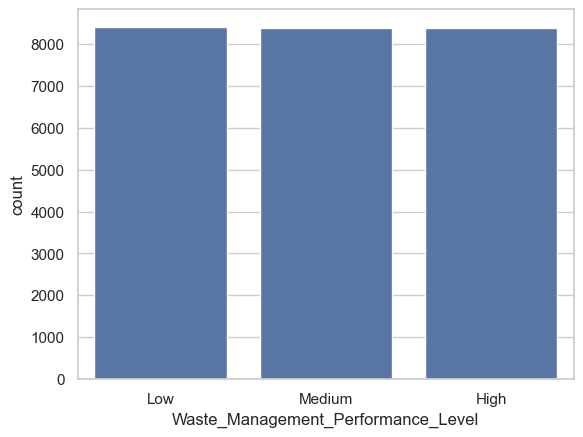

In [21]:
sns.countplot(x='Waste_Management_Performance_Level',data = df)
plt.show()

In [22]:
label = LabelEncoder()
cat_cols = categorical
for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = label.fit_transform(df[col])

In [23]:
x = df.drop(columns=['Waste_Management_Performance_Level'])
y = df[['Waste_Management_Performance_Level']]

In [24]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2,random_state=42)

In [26]:
rf = RandomForestClassifier(random_state=42)

rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = rf.predict(x_test)

In [28]:
acc_score = accuracy_score(y_test,y_pred)
print("accuracy score:",acc_score)

accuracy score: 0.9299742114659789


In [29]:
print("Training Accuracy",rf.score(x_train,y_train))
print("Testing Accuracy",rf.score(x_test,y_test))

Training Accuracy 1.0
Testing Accuracy 0.9299742114659789
